In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/netflix_titles.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df[df['date_added'].isna()]
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

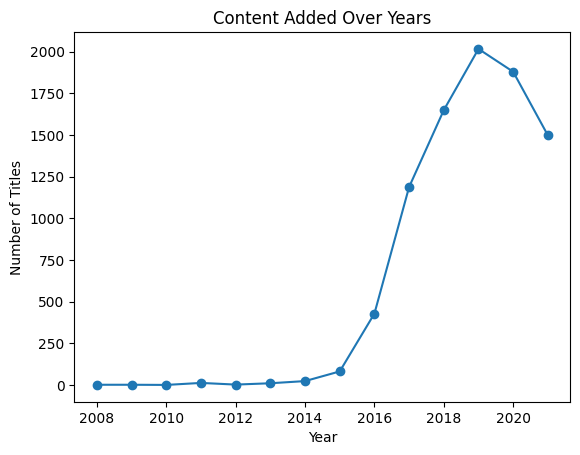

In [8]:
year_data = df['year_added'].value_counts().sort_index()

year_data.plot(kind='line', marker='o')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

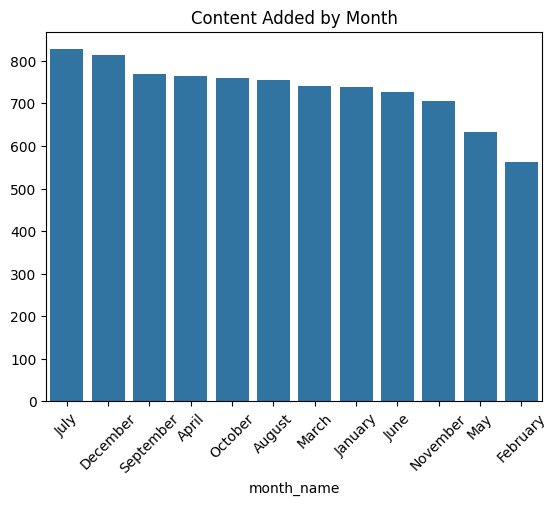

In [9]:
month_data = df['month_name'].value_counts()

sns.barplot(x=month_data.index, y=month_data.values)
plt.xticks(rotation=45)
plt.title("Content Added by Month")
plt.show()

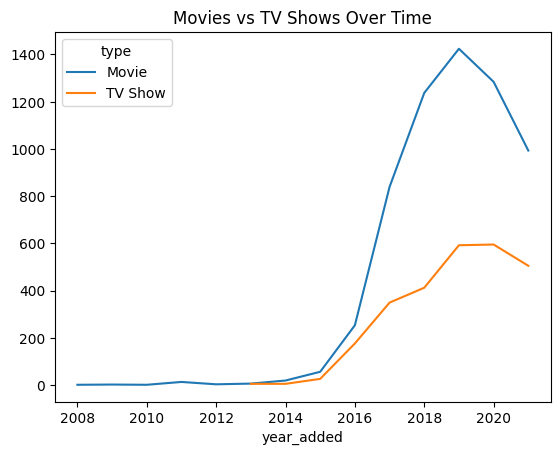

In [10]:
type_year = df.groupby(['year_added', 'type']).size().unstack()

type_year.plot(kind='line')
plt.title("Movies vs TV Shows Over Time")
plt.show()

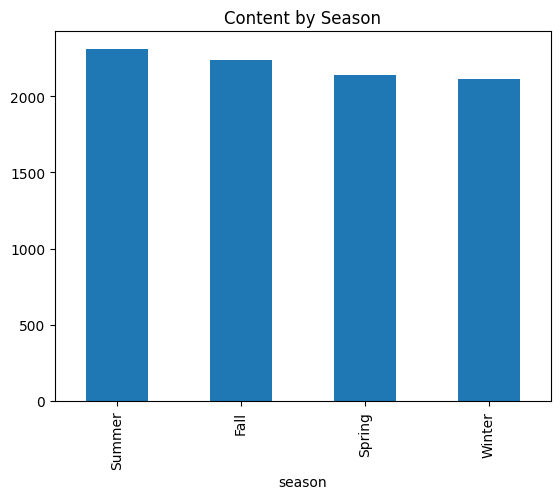

In [11]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df['season'] = df['month_added'].apply(get_season)

season_data = df['season'].value_counts()

season_data.plot(kind='bar')
plt.title("Content by Season")
plt.show()